In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from copy import deepcopy

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import OrdinalEncoder

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
SEED = 42
np.random.seed(SEED)
print('Libraries loaded.')

Libraries loaded.


In [3]:
df01 = pd.read_csv('../data/Interim/01_sales_index.csv')
df04 = pd.read_csv('../data/Interim/04_high_grown_prices.csv')
df05 = pd.read_csv('../data/Interim/05_low_grown_prices.csv')
df06 = pd.read_csv('../data/Interim/06_offgrade_dust_prices.csv')
df09 = pd.read_csv('../data/Interim/09_weather_features.csv')

print(f'01 sales index  : {df01.shape}')
print(f'04 high grown   : {df04.shape}')
print(f'05 low grown    : {df05.shape}')
print(f'06 off/dust     : {df06.shape}')
print(f'09 weather      : {df09.shape}')

01 sales index  : (26, 108)
04 high grown   : (516, 6)
05 low grown    : (1348, 6)
06 off/dust     : (1170, 6)
09 weather      : (100, 61)


In [4]:
# ── Sale-level context: minimum columns needed for baseline ─────────────────
MONTH_ORDER = {
    'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
}

# Core sale identity + supply + market + weather
# Segment-specific gross revenue columns are added per-segment below.
SALE_COLS_CORE = [
    # Identity
    'sale_id', 'sale_number', 'sale_year', 'sale_month',
    # Supply
    'total_lots', 'total_kgs', 'reprint_lots', 'reprint_quantity',
    # Market mood
    'sentiment_overall', 'sentiment_ex_estate',
    # Volume + macro
    'total_sold_weekly_2026', 'public_auction_weekly_2026',
    'sl_production_mkgs', 'fx_usd_2026',
    # Weather — the primary research driver
    'avg_weather_severity',
    'western_nuwara_eliya_weather_score',
    'uva_udapussellawa_weather_score',
    'low_grown_weather_score',
    'crop_nuwara_eliya_trend', 'crop_uva_trend', 'crop_low_grown_trend',
]

sale_meta = df01[[c for c in SALE_COLS_CORE if c in df01.columns]].copy()

# Derived columns
sale_meta['sale_month_enc']       = sale_meta['sale_month'].map(MONTH_ORDER).fillna(0).astype(int)
sale_meta['is_production_known']  = sale_meta['sl_production_mkgs'].notna().astype(int)
sale_meta['sl_production_mkgs']   = sale_meta['sl_production_mkgs'].fillna(
                                        sale_meta['sl_production_mkgs'].mean())
sale_meta['volume_yoy_change_pct']= (
    (df01['total_sold_weekly_2026'].fillna(0) - df01['total_sold_weekly_2025'].fillna(0))
    / df01['total_sold_weekly_2025'].replace(0, float('nan'))
).fillna(0)

# Sort chronologically and assign rank
sale_meta['sort_key'] = (
    sale_meta['sale_year'].fillna(9999) * 100 + sale_meta['sale_number'].fillna(99))
sale_meta = sale_meta.sort_values('sort_key').reset_index(drop=True)
sale_meta['sale_rank'] = sale_meta.index

print(f'Sales loaded : {len(sale_meta)} | Rank range: '
      f'{sale_meta["sale_rank"].min()} – {sale_meta["sale_rank"].max()}')
print(f'Columns      : {len(sale_meta.columns)}')
print(sale_meta[['sale_id', 'sale_rank', 'sale_year', 'sale_number']].to_string())


Sales loaded : 26 | Rank range: 0 – 25
Columns      : 26
                                 sale_id  sale_rank  sale_year  sale_number
0                           SALE_34_2025          0     2025.0           34
1                           SALE_35_2025          1     2025.0           35
2                           SALE_36_2025          2     2025.0           36
3                           SALE_38_2025          3     2025.0           38
4                           SALE_39_2025          4     2025.0           39
5                           SALE_40_2025          5     2025.0           40
6                           SALE_41_2025          6     2025.0           41
7                           SALE_42_2025          7     2025.0           42
8                           SALE_43_2025          8     2025.0           43
9                           SALE_44_2025          9     2025.0           44
10                          SALE_45_2025         10     2025.0           45
11                          SAL

In [5]:
# ── Pivot weather features wide by region ─────────────────────────────────────
wx = df09.copy()

# Derive composite average precipitation (not in interim file — compute here)
precip_cols = [c for c in wx.columns if 'precipitation_sum_total' in c and 'lag' not in c
               and not c.startswith('all_')]
if precip_cols:
    wx['all_regions__avg_precipitation'] = wx[precip_cols].mean(axis=1)
else:
    wx['all_regions__avg_precipitation'] = 0.0

def wx_cols(region_prefix):
    return [c for c in wx.columns if c.startswith(region_prefix + '__')]

WX_WESTERN  = wx_cols('western_high')
WX_NUWARA   = wx_cols('nuwara_eliya')
WX_UVA      = wx_cols('uva_udapussellawa')
WX_LOWGROWN = wx_cols('low_grown')
WX_ALL      = WX_WESTERN + WX_NUWARA + WX_UVA + WX_LOWGROWN + ['all_regions__avg_precipitation']

# High grown relevant: western + nuwara + uva (no low grown)
WX_HIGH_GROWN = WX_WESTERN + WX_NUWARA + WX_UVA + ['all_regions__avg_precipitation']
# Low grown relevant: low grown region
WX_LOW_GROWN  = WX_LOWGROWN + ['all_regions__avg_precipitation']

print(f'Weather cols — western_high: {len(WX_WESTERN)}, nuwara_eliya: {len(WX_NUWARA)}')
print(f'               uva_uda: {len(WX_UVA)}, low_grown: {len(WX_LOWGROWN)}')
print(f'High Grown weather features: {len(WX_HIGH_GROWN)}')
print(f'Low Grown  weather features: {len(WX_LOW_GROWN)}')
print(f'Off-Grade/Dust weather features: {len(WX_ALL)}')

Weather cols — western_high: 0, nuwara_eliya: 0
               uva_uda: 0, low_grown: 0
High Grown weather features: 1
Low Grown  weather features: 1
Off-Grade/Dust weather features: 1


In [6]:
# ── Merge price + sale context + weather ──────────────────────────────────────
hg = df04.copy()
hg['price_mid_lkr'] = (hg['price_lo_lkr'] + hg['price_hi_lkr']) / 2
hg = hg.merge(sale_meta, on='sale_id', how='left')
hg = hg.merge(wx[['sale_id'] + WX_ALL], on='sale_id', how='left')
hg = hg.dropna(subset=['price_mid_lkr']).reset_index(drop=True)
hg['price_log'] = np.log1p(hg['price_mid_lkr'])

# df04 uses 'segment' column for geographic segment names
print(f'High Grown: {len(hg)} rows, {hg["price_mid_lkr"].notna().sum()} with price')
print(f'Segment breakdown:')
print(hg.groupby('segment')['price_mid_lkr'].agg(['count','mean','std']).round(1).to_string())

High Grown: 1826 rows, 1826 with price
Segment breakdown:
                        count    mean    std
segment                                     
below_best_western        312  1193.8  112.7
best_uva                  320  1279.3  135.1
best_western              352  1372.4  155.6
brighter_udapussellawa    259  1206.9  132.5
nuwara_eliya               28  1176.4  333.5
other_udapussellawa       149  1022.3   96.4
other_uva                 136  1001.8  127.3
plainer_western           270  1046.4  137.1


In [7]:
WESTERN_SEGS   = {'best_western', 'below_best_western', 'plainer_western'}
NUWARA_SEGS    = {'nuwara_eliya'}
UVA_SEGS       = {'best_uva', 'other_uva', 'brighter_udapussellawa', 'other_udapussellawa'}

SEG_REGION = {s: 'western' for s in WESTERN_SEGS}
SEG_REGION.update({s: 'nuwara' for s in NUWARA_SEGS})
SEG_REGION.update({s: 'uva' for s in UVA_SEGS})

# Segment quality rank (higher = more premium; based on typical price ordering)
SEG_RANK = {
    'nuwara_eliya': 7, 'best_western': 6, 'best_uva': 5,
    'brighter_udapussellawa': 4, 'below_best_western': 3,
    'plainer_western': 2, 'other_uva': 1, 'other_udapussellawa': 0
}

# Grade rank (bop/bopf > pekoe_fbop > op roughly)
GRADE_RANK = {'bop': 3, 'bopf': 3, 'pekoe_fbop': 2, 'op': 1}

# df04 uses 'segment' column (not 'category')
hg['segment_name']   = hg['segment']
hg['region_group']   = hg['segment_name'].map(SEG_REGION)
hg['segment_rank']   = hg['segment_name'].map(SEG_RANK).fillna(0)
hg['grade_rank']     = hg['grade'].map(GRADE_RANK).fillna(0)
hg['is_western']     = (hg['region_group'] == 'western').astype(int)
hg['is_nuwara']      = (hg['region_group'] == 'nuwara').astype(int)
hg['is_uva']         = (hg['region_group'] == 'uva').astype(int)

# Region-routed rainfall: pick the most relevant regional rainfall for each row
hg['region_precip'] = (
    hg['is_western']  * hg.get('western_high__precipitation_sum_total', pd.Series(0, index=hg.index)).fillna(0) +
    hg['is_nuwara']   * hg.get('nuwara_eliya__precipitation_sum_total', pd.Series(0, index=hg.index)).fillna(0) +
    hg['is_uva']      * hg.get('uva_udapussellawa__precipitation_sum_total', pd.Series(0, index=hg.index)).fillna(0)
)
hg['region_precip_lag1'] = (
    hg['is_western']  * hg.get('western_high__precipitation_sum_total_lag1', pd.Series(0, index=hg.index)).fillna(0) +
    hg['is_nuwara']   * hg.get('nuwara_eliya__precipitation_sum_total_lag1', pd.Series(0, index=hg.index)).fillna(0) +
    hg['is_uva']      * hg.get('uva_udapussellawa__precipitation_sum_total_lag1', pd.Series(0, index=hg.index)).fillna(0)
)
hg['region_sunshine'] = (
    hg['is_western']  * hg.get('western_high__sunshine_duration_total', pd.Series(0, index=hg.index)).fillna(0) +
    hg['is_nuwara']   * hg.get('nuwara_eliya__sunshine_duration_total', pd.Series(0, index=hg.index)).fillna(0) +
    hg['is_uva']      * hg.get('uva_udapussellawa__sunshine_duration_total', pd.Series(0, index=hg.index)).fillna(0)
)
hg['region_temp'] = (
    hg['is_western']  * hg.get('western_high__temperature_2m_mean_mean', pd.Series(0, index=hg.index)).fillna(0) +
    hg['is_nuwara']   * hg.get('nuwara_eliya__temperature_2m_mean_mean', pd.Series(0, index=hg.index)).fillna(0) +
    hg['is_uva']      * hg.get('uva_udapussellawa__temperature_2m_mean_mean', pd.Series(0, index=hg.index)).fillna(0)
)

# Interactions: segment premium × rainfall (weather sensitivity varies by segment quality)
hg['seg_rank_x_precip']  = hg['segment_rank'] * hg['region_precip']
hg['seg_rank_x_precip1'] = hg['segment_rank'] * hg['region_precip_lag1']

print('High Grown feature engineering done.')
print(f'Region breakdown: {hg["region_group"].value_counts().to_dict()}')

High Grown feature engineering done.
Region breakdown: {'western': 934, 'uva': 864, 'nuwara': 28}


In [8]:
# ── High Grown feature list ────────────────────────────────────────────────────
# Shared sale-level features used by all segment models
# Shared sale-level features — subset of SALE_COLS_CORE plus derived columns.
# Segment models add their own gross revenue signals on top of these.
SALE_FEATS = [
    'sale_rank', 'sale_month_enc', 'sale_number',
    'total_lots', 'total_kgs', 'reprint_lots', 'reprint_quantity',
    'sl_production_mkgs', 'is_production_known',
    'sentiment_overall', 'sentiment_ex_estate',
    'public_auction_weekly_2026', 'total_sold_weekly_2026',
    'volume_yoy_change_pct', 'fx_usd_2026',
]

# High-grown gross revenue signals (western + uva breakdown available)
HG_GROSS = [
    'gross_lkr_weekly_western_high_2026', 'gross_lkr_weekly_western_high_2025',
    'gross_lkr_weekly_uva_high_2026',     'gross_lkr_weekly_uva_high_2025',
    'gross_lkr_weekly_ctc_high_2026',
]

HG_STRUCT = [
    'segment_rank', 'grade_rank', 'is_western', 'is_nuwara', 'is_uva',
]

HG_WX_ENGINEERED = [
    'region_precip', 'region_precip_lag1', 'region_sunshine', 'region_temp',
    'seg_rank_x_precip', 'seg_rank_x_precip1',
    'western_nuwara_eliya_weather_score', 'uva_udapussellawa_weather_score',
    'crop_western_trend', 'crop_nuwara_eliya_trend', 'crop_uva_trend',
]

HG_FEATURES = SALE_FEATS + HG_GROSS + HG_STRUCT + HG_WX_ENGINEERED
# Only keep features that exist in the dataframe
HG_FEATURES = [c for c in HG_FEATURES if c in hg.columns]

print(f'High Grown model features: {len(HG_FEATURES)}')
print(HG_FEATURES)


High Grown model features: 30
['sale_rank', 'sale_month_enc', 'sale_number', 'total_lots', 'total_kgs', 'reprint_lots', 'reprint_quantity', 'sl_production_mkgs', 'is_production_known', 'sentiment_overall', 'sentiment_ex_estate', 'public_auction_weekly_2026', 'total_sold_weekly_2026', 'volume_yoy_change_pct', 'fx_usd_2026', 'segment_rank', 'grade_rank', 'is_western', 'is_nuwara', 'is_uva', 'region_precip', 'region_precip_lag1', 'region_sunshine', 'region_temp', 'seg_rank_x_precip', 'seg_rank_x_precip1', 'western_nuwara_eliya_weather_score', 'uva_udapussellawa_weather_score', 'crop_nuwara_eliya_trend', 'crop_uva_trend']


In [9]:
lg = df05.copy()
lg['price_mid_lkr'] = (lg['price_lo_lkr'] + lg['price_hi_lkr']) / 2
lg = lg.merge(sale_meta, on='sale_id', how='left')
lg = lg.merge(wx[['sale_id'] + WX_ALL], on='sale_id', how='left')
lg = lg.dropna(subset=['price_mid_lkr']).reset_index(drop=True)
lg['price_log'] = np.log1p(lg['price_mid_lkr'])

print(f'Low Grown: {len(lg)} rows')
print('Grade Ã— Tier mean prices (LKR):')
pivot = lg.pivot_table(values='price_mid_lkr', index='grade', columns='tier', aggfunc='mean')
tier_order = ['select_best','best','below_best','others']
print(pivot[[c for c in tier_order if c in pivot.columns]].round(0).to_string())

Low Grown: 5188 rows
Grade Ã— Tier mean prices (LKR):
tier         select_best    best  below_best  others
grade                                               
bop               1879.0  1459.0      1204.0   954.0
bop1              2662.0  2001.0      1378.0  1049.0
bopf              1458.0   959.0       869.0   823.0
fbop              2134.0  1541.0      1280.0   944.0
fbop1             1784.0  1447.0      1263.0   953.0
fbopf             1660.0  1407.0      1223.0   954.0
fbopf1            1637.0  1457.0      1296.0   971.0
fbopf_tippy       4845.0  3614.0      2650.0  1050.0
op                1581.0  1428.0      1312.0  1048.0
op1               3159.0  2612.0      1970.0  1199.0
opa               1662.0  1371.0      1250.0  1032.0
pek1              2150.0  1633.0      1399.0  1118.0
pekoe             2005.0  1410.0      1284.0  1043.0


In [10]:
# Grade groups: flowery (premium) / bop-type (standard) / op-type (commodity)
FLOWERY_GRADES  = {'fbopf_tippy', 'fbopf', 'fbopf1'}
BOP_GRADES      = {'fbop', 'fbop1', 'bop', 'bopf', 'bop1'}
OP_GRADES       = {'op', 'op1', 'opa', 'pekoe', 'pek1'}

def grade_group(g):
    if g in FLOWERY_GRADES: return 2  # premium
    if g in BOP_GRADES:     return 1  # standard
    return 0                          # commodity

TIER_RANK = {'select_best': 3, 'best': 2, 'below_best': 1, 'others': 0}

lg['grade_group']   = lg['grade'].apply(grade_group)
lg['is_flowery']    = (lg['grade'] == 'fbopf_tippy').astype(int)  # ultra-premium tippy
lg['tier_rank']     = lg['tier'].map(TIER_RANK).fillna(0)
lg['grade_x_tier']  = lg['grade_group'] * lg['tier_rank']         # interaction
lg['is_select']     = (lg['tier'] == 'select_best').astype(int)

# Low grown-specific weather (region-routed already)
lg['lg_precip']     = lg.get('low_grown__precipitation_sum_total', pd.Series(0, index=lg.index)).fillna(0)
lg['lg_precip_lag1']= lg.get('low_grown__precipitation_sum_total_lag1', pd.Series(0, index=lg.index)).fillna(0)
lg['lg_precip_lag2']= lg.get('low_grown__precipitation_sum_total_lag2', pd.Series(0, index=lg.index)).fillna(0)
lg['lg_sunshine']   = lg.get('low_grown__sunshine_duration_total', pd.Series(0, index=lg.index)).fillna(0)
lg['lg_temp']       = lg.get('low_grown__temperature_2m_mean_mean', pd.Series(0, index=lg.index)).fillna(0)
lg['lg_humidity']   = lg.get('low_grown__relative_humidity_2m_max_mean', pd.Series(0, index=lg.index)).fillna(0)

# Weather sensitivity interactions
lg['flowery_x_precip'] = lg['is_flowery'] * lg['lg_precip']       # tippy premium vs rainfall
lg['tier_x_precip']    = lg['tier_rank']  * lg['lg_precip']
lg['tier_x_sunshine']  = lg['tier_rank']  * lg['lg_sunshine']

print('Low Grown feature engineering done.')
print(f'Grade groups â€” flowery: {(lg["grade_group"]==2).sum()}, bop: {(lg["grade_group"]==1).sum()}, op: {(lg["grade_group"]==0).sum()}')

Low Grown feature engineering done.
Grade groups â€” flowery: 1148, bop: 2020, op: 2020


In [11]:
LG_STRUCT = [
    'grade_group', 'is_flowery', 'tier_rank', 'grade_x_tier', 'is_select',
]

# Low-grown gross revenue signals
LG_GROSS = [
    'gross_lkr_weekly_orthodox_low_2026', 'gross_lkr_weekly_orthodox_low_2025',
    'gross_lkr_weekly_ctc_low_2026',      'gross_lkr_weekly_ctc_low_2025',
]

LG_WX = [
    'lg_precip', 'lg_precip_lag1', 'lg_precip_lag2',
    'lg_sunshine', 'lg_temp', 'lg_humidity',
    'flowery_x_precip', 'tier_x_precip', 'tier_x_sunshine',
    'low_grown_weather_score', 'crop_low_grown_trend',
    'low_grown__text_condition_score', 'low_grown__text_has_rain',
    'low_grown__windspeed_10m_max_mean',
    'all_regions__avg_precipitation',
]

LG_FEATURES = SALE_FEATS + LG_GROSS + LG_STRUCT + LG_WX
LG_FEATURES = [c for c in LG_FEATURES if c in lg.columns]

print(f'Low Grown model features: {len(LG_FEATURES)}')
print(LG_FEATURES)

Low Grown model features: 32
['sale_rank', 'sale_month_enc', 'sale_number', 'total_lots', 'total_kgs', 'reprint_lots', 'reprint_quantity', 'sl_production_mkgs', 'is_production_known', 'sentiment_overall', 'sentiment_ex_estate', 'public_auction_weekly_2026', 'total_sold_weekly_2026', 'volume_yoy_change_pct', 'fx_usd_2026', 'grade_group', 'is_flowery', 'tier_rank', 'grade_x_tier', 'is_select', 'lg_precip', 'lg_precip_lag1', 'lg_precip_lag2', 'lg_sunshine', 'lg_temp', 'lg_humidity', 'flowery_x_precip', 'tier_x_precip', 'tier_x_sunshine', 'low_grown_weather_score', 'crop_low_grown_trend', 'all_regions__avg_precipitation']


In [12]:
og = df06[df06['category_type'] == 'off_grade'].copy()
og['price_mid_lkr'] = (og['price_lo_lkr'] + og['price_hi_lkr']) / 2
og = og.merge(sale_meta, on='sale_id', how='left')
og = og.merge(wx[['sale_id'] + WX_ALL], on='sale_id', how='left')
og = og.dropna(subset=['price_mid_lkr']).reset_index(drop=True)
og['price_log'] = np.log1p(og['price_mid_lkr'])

print(f'Off-Grade: {len(og)} rows with price')
print('Category — Elevation mean prices:')
print(og.groupby(['category','elevation'])['price_mid_lkr']
        .mean().unstack('elevation').round(0).to_string())

def parse_og_category(cat):
    process = 'orthodox' if 'orthodox' in cat or 'orth' in cat else \
              'ctc'      if 'ctc' in cat else 'mixed'
    prod    = 'fannings' if 'fannings'  in cat else \
              'brokens'  if 'brokens'   in cat else \
              'bop1a'    if 'bop1a'     in cat else 'other'
    quality = 'better'   if 'better'    in cat else \
              'good'     if 'good'      in cat else 'other'
    return process, prod, quality

og[['process_type','product_class','quality_level']] = og['category'].apply(
    lambda c: pd.Series(parse_og_category(c)))

PROCESS_ENC = {'orthodox': 2, 'ctc': 1, 'mixed': 0}
PROD_ENC    = {'fannings': 3, 'brokens': 2, 'bop1a': 1, 'other': 0}
QUAL_ENC    = {'better': 2, 'good': 1, 'other': 0}
ELEV_ENC    = {'high': 2, 'medium': 1, 'low': 0}

og['process_enc'] = og['process_type'].map(PROCESS_ENC).fillna(0)
og['product_enc'] = og['product_class'].map(PROD_ENC).fillna(0)
og['quality_enc'] = og['quality_level'].map(QUAL_ENC).fillna(0)
og['elevation_enc'] = og['elevation'].map(ELEV_ENC).fillna(1)

# Combined score: higher-grade products at higher elevation tend to command premium
og['quality_x_elevation'] = og['quality_enc'] * og['elevation_enc']
og['product_x_process']   = og['product_enc'] * og['process_enc']

# Weather: use all regions (off-grade is blended from all elevations)
og['avg_precip']     = og.get('all_regions__avg_precipitation', pd.Series(0)).fillna(0)
og['high_precip']    = og.get('western_high__precipitation_sum_total', pd.Series(0)).fillna(0)
og['low_precip']     = og.get('low_grown__precipitation_sum_total', pd.Series(0)).fillna(0)
og['high_precip_l1'] = og.get('western_high__precipitation_sum_total_lag1', pd.Series(0)).fillna(0)

# Elevation-routed rainfall interaction
og['elev_precip'] = (
    (og['elevation_enc'] == 2) * og['high_precip'] +
    (og['elevation_enc'] == 1) * og['avg_precip'] +
    (og['elevation_enc'] == 0) * og['low_precip']
)

print('Off-Grade feature engineering done.')
print(og[['process_type','product_class','quality_level','elevation']].value_counts().head(10).to_string())

Off-Grade: 1885 rows with price
Category — Elevation mean prices:
elevation                   high     low  medium
category                                        
bop1a_better               854.0  1100.0   942.0
bop1a_other                719.0   671.0   698.0
brokens_good               898.0  1006.0   985.0
brokens_other              648.0   612.0   636.0
fannings_ctc_better        800.0   990.0   848.0
fannings_ctc_other         675.0   655.0   672.0
fannings_orthodox_better  1055.0   880.0   971.0
fannings_orthodox_other    701.0   664.0   678.0
Off-Grade feature engineering done.
process_type  product_class  quality_level  elevation
orthodox      fannings       better         high         101
                             other          high         101
                                            medium       101
ctc           fannings       other          medium       101
mixed         brokens        good           high         101
                                            mediu

In [13]:
OG_STRUCT = [
    'process_enc', 'product_enc', 'quality_enc', 'elevation_enc',
    'quality_x_elevation', 'product_x_process',
]

# Off-grade uses all elevation gross revenue signals
OG_GROSS = [
    'gross_lkr_weekly_western_high_2026', 'gross_lkr_weekly_uva_high_2026',
    'gross_lkr_weekly_uva_medium_2026',
    'gross_lkr_weekly_orthodox_low_2026', 'gross_lkr_weekly_total_2026',
]

OG_WX = [
    'avg_precip', 'high_precip', 'low_precip', 'high_precip_l1', 'elev_precip',
    'avg_weather_severity',
    'western_nuwara_eliya_weather_score', 'uva_udapussellawa_weather_score', 'low_grown_weather_score',
    'crop_western_trend', 'crop_uva_trend', 'crop_low_grown_trend',
]

OG_FEATURES = SALE_FEATS + OG_GROSS + OG_STRUCT + OG_WX
OG_FEATURES = [c for c in OG_FEATURES if c in og.columns]

print(f'Off-Grade model features: {len(OG_FEATURES)}')

Off-Grade model features: 32


In [14]:
du = df06[df06['category_type'] == 'dust'].copy()
du['price_mid_lkr'] = (du['price_lo_lkr'] + du['price_hi_lkr']) / 2
du = du.merge(sale_meta, on='sale_id', how='left')
du = du.merge(wx[['sale_id'] + WX_ALL], on='sale_id', how='left')
du = du.dropna(subset=['price_mid_lkr']).reset_index(drop=True)
du['price_log'] = np.log1p(du['price_mid_lkr'])

print(f'Dust: {len(du)} rows with price')
print('Category A — Elevation mean prices:')
print(du.groupby(['category','elevation'])['price_mid_lkr']
        .mean().unstack('elevation').round(0).to_string())

# ── Dust feature engineering ───────────────────────────────────────────────────
def parse_dust_category(cat):
    dust_type = 'primary'   if 'primary'   in cat else \
                'secondary' if 'secondary' in cat else 'other'
    process   = 'orthodox'  if 'orth'      in cat or 'orthodox' in cat else \
                'ctc'       if 'ctc'       in cat else 'other'
    quality   = 'better'    if 'better'    in cat else \
                'below_best'if 'below_best'in cat else 'other'
    return dust_type, process, quality

du[['dust_type','process_type','quality_level']] = du['category'].apply(
    lambda c: pd.Series(parse_dust_category(c)))

DUSTTYPE_ENC = {'primary': 1, 'secondary': 0, 'other': 0}
du['dusttype_enc'] = du['dust_type'].map(DUSTTYPE_ENC).fillna(0)
du['process_enc']  = du['process_type'].map(PROCESS_ENC).fillna(0)
du['quality_enc']  = du['quality_level'].map({'better': 2, 'below_best': 1, 'other': 0}).fillna(0)
du['elevation_enc']= du['elevation'].map(ELEV_ENC).fillna(1)

du['quality_x_elevation'] = du['quality_enc'] * du['elevation_enc']
du['type_x_process']      = du['dusttype_enc'] * du['process_enc']

du['avg_precip']     = du.get('all_regions__avg_precipitation', pd.Series(0, index=du.index)).fillna(0)
du['high_precip']    = du.get('western_high__precipitation_sum_total', pd.Series(0, index=du.index)).fillna(0)
du['low_precip']     = du.get('low_grown__precipitation_sum_total', pd.Series(0, index=du.index)).fillna(0)
du['high_precip_l1'] = du.get('western_high__precipitation_sum_total_lag1', pd.Series(0, index=du.index)).fillna(0)
du['elev_precip'] = (
    (du['elevation_enc'] == 2) * du['high_precip'] +
    (du['elevation_enc'] == 1) * du['avg_precip'] +
    (du['elevation_enc'] == 0) * du['low_precip']
)

DU_STRUCT = [
    'dusttype_enc', 'process_enc', 'quality_enc', 'elevation_enc',
    'quality_x_elevation', 'type_x_process',
]

DU_GROSS = [
    'gross_lkr_weekly_western_high_2026', 'gross_lkr_weekly_uva_medium_2026',
    'gross_lkr_weekly_orthodox_low_2026', 'gross_lkr_weekly_total_2026',
]

DU_WX = OG_WX.copy()  # same weather feature set as off-grade

DU_FEATURES = SALE_FEATS + DU_GROSS + DU_STRUCT + DU_WX
DU_FEATURES = [c for c in DU_FEATURES if c in du.columns]

print(f'Dust feature engineering done.')
print(f'Dust model features: {len(DU_FEATURES)}')

Dust: 1983 rows with price
Category A — Elevation mean prices:
elevation                  high     low  medium
category                                       
primary_ctc_better       1142.0  1295.0  1143.0
primary_ctc_other        1038.0  1002.0   986.0
primary_orth_below_best  1117.0   870.0   961.0
primary_orth_better      1421.0  1020.0  1161.0
primary_orth_other        939.0   703.0   745.0
secondary_better         1125.0   996.0   978.0
secondary_other           841.0   752.0   731.0
Dust feature engineering done.
Dust model features: 32


In [15]:
def time_split(df, n_test_sales=5, rank_col='sale_rank'):
    """Split by sale rank: last n_test_sales unique ranks’ test."""
    ranks = sorted(df[rank_col].unique())
    test_ranks  = set(ranks[-n_test_sales:])
    train_ranks = set(ranks[:-n_test_sales])
    train = df[df[rank_col].isin(train_ranks)].copy()
    test  = df[df[rank_col].isin(test_ranks)].copy()
    return train, test


hg_train, hg_test = time_split(hg)
lg_train, lg_test = time_split(lg)
og_train, og_test = time_split(og)
du_train, du_test = time_split(du)

for name, tr, te in [('High Grown', hg_train, hg_test),
                     ('Low Grown',  lg_train, lg_test),
                     ('Off-Grade',  og_train, og_test),
                     ('Dust',       du_train, du_test)]:
    print(f'{name:<12s}: train={len(tr):4d}  test={len(te):4d}')

High Grown  : train=1564  test= 262
Low Grown   : train=4332  test= 856
Off-Grade   : train=1572  test= 313
Dust        : train=1648  test= 335


In [16]:
TARGET = 'price_log'


def make_tree_pipe(estimator):
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('model',  estimator),
    ])


def train_eval(train_df, test_df, features, label):
    """Train RF + GB on a segment and return metrics dict."""
    X_tr = train_df[features].values
    y_tr = train_df[TARGET].values
    X_te = test_df[features].values
    y_te = test_df[TARGET].values

    models = {
        'Random Forest': make_tree_pipe(
            RandomForestRegressor(n_estimators=300, max_depth=None,
                                  min_samples_leaf=3, n_jobs=-1, random_state=SEED)),
        'Gradient Boosting': make_tree_pipe(
            GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                      learning_rate=0.05, subsample=0.8,
                                      min_samples_leaf=3, random_state=SEED)),
    }

    rows = []
    fitted = {}
    for mname, pipe in models.items():
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_te)
        
        y_true_lkr = np.expm1(y_te)
        y_pred_lkr = np.expm1(pred)
        
        mae  = mean_absolute_error(y_true_lkr, y_pred_lkr)
        rmse = np.sqrt(mean_squared_error(y_true_lkr, y_pred_lkr))
        r2   = r2_score(y_te, pred)
        mape = np.mean(np.abs((y_true_lkr - y_pred_lkr) / (y_true_lkr + 1e-9))) * 100
        
        rows.append({'Segment': label, 'Model': mname,
                     'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape,
                     'n_train': len(X_tr), 'n_test': len(X_te)})
        fitted[mname] = (pipe, features)
    
    return pd.DataFrame(rows), fitted


print('Training all segments...')
hg_res, hg_models = train_eval(hg_train, hg_test, HG_FEATURES, 'High Grown')
print('  High Grown done')
lg_res, lg_models = train_eval(lg_train, lg_test, LG_FEATURES, 'Low Grown')
print('  Low Grown done')
og_res, og_models = train_eval(og_train, og_test, OG_FEATURES, 'Off-Grade')
print('  Off-Grade done')
du_res, du_models = train_eval(du_train, du_test, DU_FEATURES, 'Dust')
print('  Dust done')

all_results = pd.concat([hg_res, lg_res, og_res, du_res], ignore_index=True)
print('Done.')

Training all segments...
  High Grown done
  Low Grown done
  Off-Grade done
  Dust done
Done.


In [17]:
print('=' * 75)
print('SEGMENT MODEL RESULTS (Test Set)')
print('=' * 75)
for seg in ['High Grown', 'Low Grown', 'Off-Grade', 'Dust']:
    sub = all_results[all_results['Segment'] == seg]
    print(f'\n--- {seg} (train={sub["n_train"].iloc[0]}, test={sub["n_test"].iloc[0]}) ---')
    print(sub[['Model','RMSE','MAE','R2','MAPE']].set_index('Model')
            .rename(columns={'RMSE':'RMSE(LKR)','MAE':'MAE(LKR)','MAPE':'MAPE(%)'})
            .round(2).to_string())
print()

SEGMENT MODEL RESULTS (Test Set)

--- High Grown (train=1564, test=262) ---
                   RMSE(LKR)  MAE(LKR)    R2  MAPE(%)
Model                                                
Random Forest         124.42     77.42  0.74     6.72
Gradient Boosting     135.37     85.69  0.71     7.36

--- Low Grown (train=4332, test=856) ---
                   RMSE(LKR)  MAE(LKR)    R2  MAPE(%)
Model                                                
Random Forest         347.94    215.54  0.73    12.70
Gradient Boosting     349.99    213.71  0.73    12.56

--- Off-Grade (train=1572, test=313) ---
                   RMSE(LKR)  MAE(LKR)    R2  MAPE(%)
Model                                                
Random Forest          34.88     27.81  0.95     3.83
Gradient Boosting      34.99     28.39  0.95     3.94

--- Dust (train=1648, test=335) ---
                   RMSE(LKR)  MAE(LKR)    R2  MAPE(%)
Model                                                
Random Forest          49.78     38.11  0.93   

In [18]:
for seg in ['High Grown', 'Low Grown', 'Off-Grade', 'Dust']:
    sub = all_results[all_results['Segment'] == seg]
    print(f'\n--- {seg} (train={sub["n_train"].iloc[0]}, test={sub["n_test"].iloc[0]}) ---')
    print(sub[['Model','RMSE','MAE','R2','MAPE']].set_index('Model')
            .rename(columns={'RMSE':'RMSE(LKR)','MAE':'MAE(LKR)','MAPE':'MAPE(%)'})
            .round(2).to_string())
print()


--- High Grown (train=1564, test=262) ---
                   RMSE(LKR)  MAE(LKR)    R2  MAPE(%)
Model                                                
Random Forest         124.42     77.42  0.74     6.72
Gradient Boosting     135.37     85.69  0.71     7.36

--- Low Grown (train=4332, test=856) ---
                   RMSE(LKR)  MAE(LKR)    R2  MAPE(%)
Model                                                
Random Forest         347.94    215.54  0.73    12.70
Gradient Boosting     349.99    213.71  0.73    12.56

--- Off-Grade (train=1572, test=313) ---
                   RMSE(LKR)  MAE(LKR)    R2  MAPE(%)
Model                                                
Random Forest          34.88     27.81  0.95     3.83
Gradient Boosting      34.99     28.39  0.95     3.94

--- Dust (train=1648, test=335) ---
                   RMSE(LKR)  MAE(LKR)    R2  MAPE(%)
Model                                                
Random Forest          49.78     38.11  0.93     4.06
Gradient Boosting      48.

Best model per segment:
  High Grown   -> Random Forest           R2=0.744  RMSE=124 LKR
  Low Grown    -> Random Forest           R2=0.729  RMSE=348 LKR

Computing SHAP values...
  High Grown: computed (n_test=262, n_feats=30) | top weather feat = western_nuwara_eliya_weather_score
  Low Grown: computed (n_test=856, n_feats=32) | top weather feat = all_regions__avg_precipitation
All SHAP values ready.


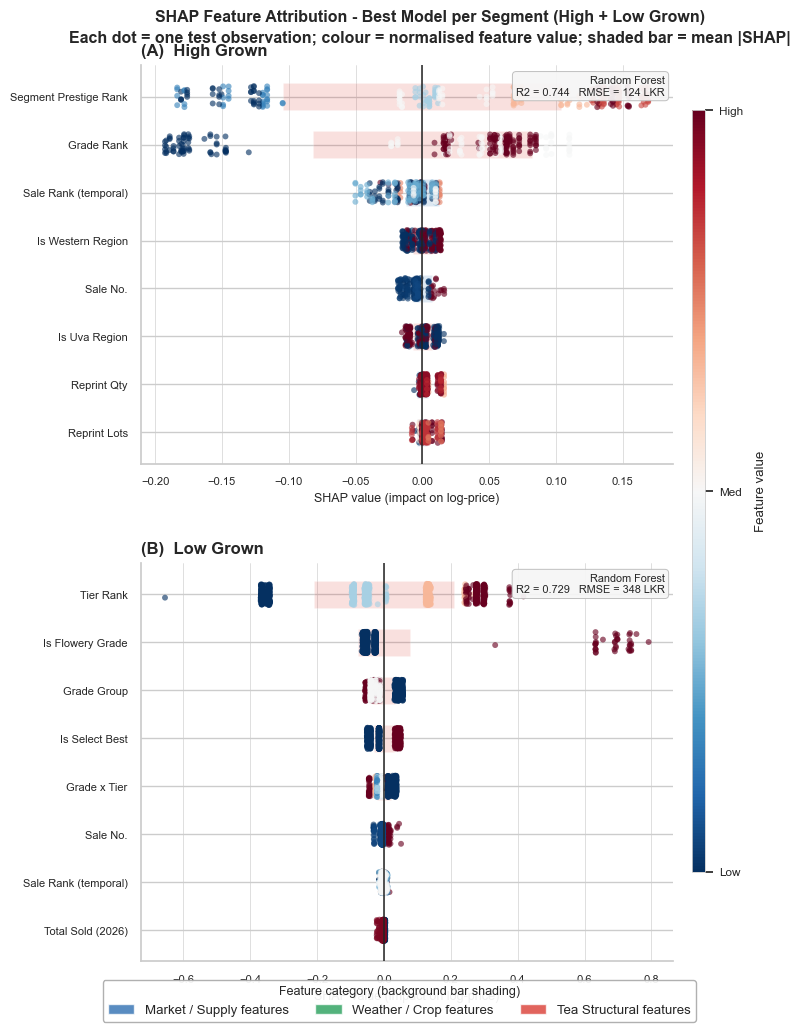


Figure A saved -> reports/figures/fig_shap_summary_hg_lg.{pdf,png}


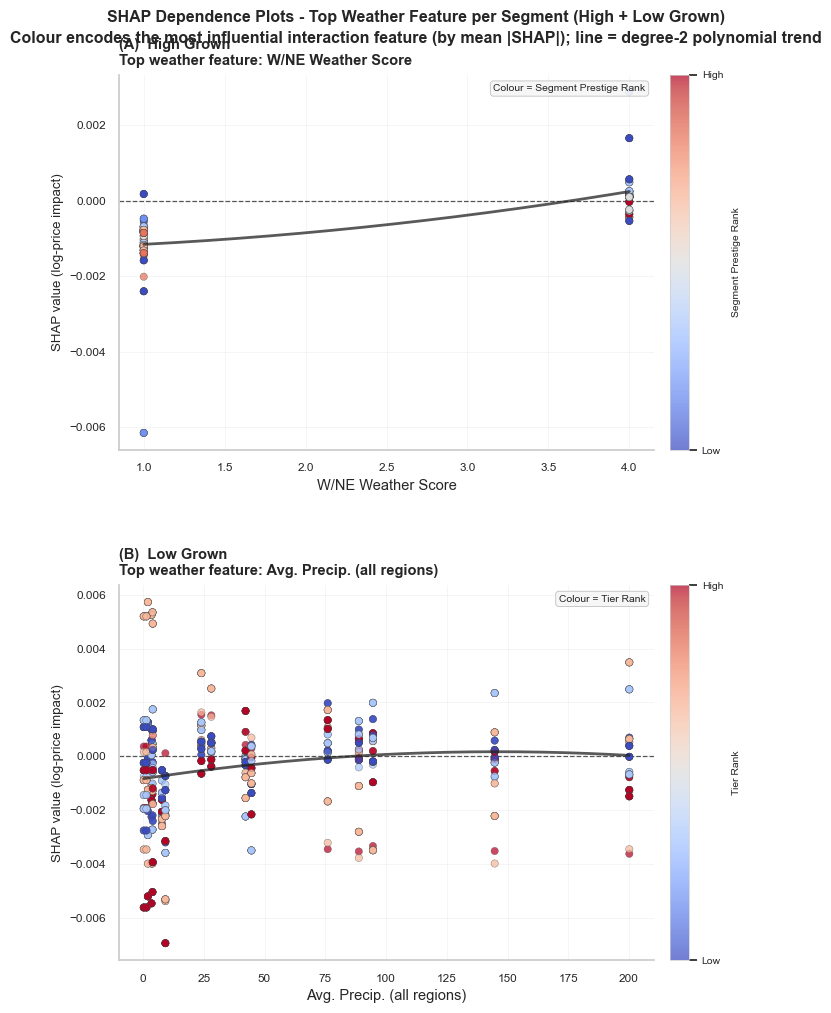


Figure B saved -> reports/figures/fig_shap_dependence_weather_hg_lg.{pdf,png}

SHAP Top-8 Features per Segment

High Grown  [Random Forest  R2=0.744]
  1. Segment Prestige Rank                mean|SHAP|=0.10407
  2. Grade Rank                           mean|SHAP|=0.08202
  3. Sale Rank (temporal)                 mean|SHAP|=0.01227
  4. Is Western Region                    mean|SHAP|=0.00718
  5. Sale No.                             mean|SHAP|=0.00696
  6. Is Uva Region                        mean|SHAP|=0.00687
  7. Reprint Qty                          mean|SHAP|=0.00397
  8. Reprint Lots                         mean|SHAP|=0.00368

Low Grown  [Random Forest  R2=0.729]
  1. Tier Rank                            mean|SHAP|=0.20972
  2. Is Flowery Grade                     mean|SHAP|=0.07750
  3. Grade Group                          mean|SHAP|=0.03415
  4. Is Select Best                       mean|SHAP|=0.02905
  5. Grade x Tier                         mean|SHAP|=0.02038
  6. Sale No.     

In [26]:
# ===============================================================================
# SHAP Analysis - Best Model Per Segment (High Grown + Low Grown only)
# Produces: (a) 2-panel beeswarm summary figure  (b) weather dependence plots
# ===============================================================================
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.cm import ScalarMappable
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# -- 1. Feature label mapping (publication-quality names) -----------------------
FEAT_LABELS = {
    # Sale-level
    'sale_rank':               'Sale Rank (temporal)',
    'sale_month_enc':          'Sale Month',
    'sale_number':             'Sale No.',
    'total_lots':              'Total Lots',
    'total_kgs':               'Total Volume (kg)',
    'reprint_lots':            'Reprint Lots',
    'reprint_quantity':        'Reprint Qty',
    'sl_production_mkgs':      'SL Production (M kg)',
    'is_production_known':     'Production Data Known',
    'sentiment_overall':       'Market Sentiment',
    'sentiment_ex_estate':     'Ex-estate Sentiment',
    'public_auction_weekly_2026': 'Auction Vol. (2026)',
    'total_sold_weekly_2026':  'Total Sold (2026)',
    'volume_yoy_change_pct':   'Volume YoY Delta (%)',
    'fx_usd_2026':             'USD/LKR Rate',
    # Gross revenue
    'gross_lkr_weekly_western_high_2026': 'Gross Rev - W.High 2026',
    'gross_lkr_weekly_western_high_2025': 'Gross Rev - W.High 2025',
    'gross_lkr_weekly_uva_high_2026':     'Gross Rev - Uva High 2026',
    'gross_lkr_weekly_uva_high_2025':     'Gross Rev - Uva High 2025',
    'gross_lkr_weekly_ctc_high_2026':     'Gross Rev - CTC High 2026',
    'gross_lkr_weekly_orthodox_low_2026': 'Gross Rev - Orth. Low 2026',
    'gross_lkr_weekly_orthodox_low_2025': 'Gross Rev - Orth. Low 2025',
    'gross_lkr_weekly_ctc_low_2026':      'Gross Rev - CTC Low 2026',
    'gross_lkr_weekly_ctc_low_2025':      'Gross Rev - CTC Low 2025',
    # HG structural
    'segment_rank':   'Segment Prestige Rank',
    'grade_rank':     'Grade Rank',
    'is_western':     'Is Western Region',
    'is_nuwara':      'Is Nuwara Eliya',
    'is_uva':         'Is Uva Region',
    # HG weather
    'region_precip':           'Precipitation (region)',
    'region_precip_lag1':      'Precip. Lag-1 wk',
    'region_sunshine':         'Sunshine Hours',
    'region_temp':             'Temperature',
    'seg_rank_x_precip':       'Seg Rank x Precip.',
    'seg_rank_x_precip1':      'Seg Rank x Precip.(t-1)',
    'western_nuwara_eliya_weather_score': 'W/NE Weather Score',
    'uva_udapussellawa_weather_score':    'Uva/Uda Weather Score',
    'crop_western_trend':      'Western Crop Trend',
    'crop_nuwara_eliya_trend': 'Nuwara Eliya Crop Trend',
    'crop_uva_trend':          'Uva Crop Trend',
    # LG structural
    'grade_group':   'Grade Group',
    'is_flowery':    'Is Flowery Grade',
    'tier_rank':     'Tier Rank',
    'grade_x_tier':  'Grade x Tier',
    'is_select':     'Is Select Best',
    # LG weather
    'lg_precip':            'Precipitation (LG)',
    'lg_precip_lag1':       'Precip. Lag-1 wk (LG)',
    'lg_precip_lag2':       'Precip. Lag-2 wk (LG)',
    'lg_sunshine':          'Sunshine Hrs (LG)',
    'lg_temp':              'Temperature (LG)',
    'lg_humidity':          'Humidity (LG)',
    'flowery_x_precip':     'Flowery x Precip.',
    'tier_x_precip':        'Tier x Precip.',
    'tier_x_sunshine':      'Tier x Sunshine',
    'low_grown_weather_score':        'LG Composite Weather',
    'crop_low_grown_trend':           'LG Crop Trend',
    'low_grown__text_condition_score': 'LG Text Condition',
    'low_grown__text_has_rain':        'LG Text: Rain Mention',
    'low_grown__windspeed_10m_max_mean': 'Wind Speed (LG)',
    'all_regions__avg_precipitation':  'Avg. Precip. (all regions)',
}

def feat_label(f):
    return FEAT_LABELS.get(f, f.replace('_', ' ').title())

# -- 2. Feature category for colour-coded bar backgrounds -----------------------
_ALL_WX = set(HG_WX_ENGINEERED) | set(LG_WX)

def feat_category(f):
    if f in set(SALE_FEATS):    return 'market'
    if f in _ALL_WX:            return 'weather'
    kw = ('precip','sunshine','temp','humid','wind','weather','crop','trend')
    if any(k in f for k in kw): return 'weather'
    return 'structural'

CAT_COLORS = {'market': '#2166ac', 'weather': '#1a9850', 'structural': '#d73027'}

# -- 3. Segment config -----------------------------------------------------------
SEGMENTS = ['High Grown', 'Low Grown']
SEG_CFG  = {
    'High Grown': {'train': hg_train, 'test': hg_test,
                   'models': hg_models, 'wx': HG_WX_ENGINEERED},
    'Low Grown':  {'train': lg_train, 'test': lg_test,
                   'models': lg_models, 'wx': LG_WX},
}

# -- 4. Identify best model per segment (highest R2) ----------------------------
print('Best model per segment:')
best = {}
for seg in SEGMENTS:
    sub = all_results[all_results['Segment'] == seg]
    row = sub.loc[sub['R2'].idxmax()]
    best[seg] = {'name': row['Model'], 'r2': row['R2'], 'rmse': row['RMSE']}
    print(f"  {seg:<12s} -> {row['Model']:<22s}  R2={row['R2']:.3f}  RMSE={row['RMSE']:.0f} LKR")

# -- 5. Compute SHAP values ------------------------------------------------------
print('\nComputing SHAP values...')
shap_store = {}

for seg in SEGMENTS:
    cfg  = SEG_CFG[seg]
    info = best[seg]
    pipe, feats = cfg['models'][info['name']]

    imputer = pipe.named_steps['impute']
    model   = pipe.named_steps['model']

    X_tr = imputer.transform(cfg['train'][feats].values)
    X_te = imputer.transform(cfg['test'][feats].values)

    # Align feature names with transformed matrix (SimpleImputer can drop all-missing cols)
    feat_keep_mask = ~pd.isna(imputer.statistics_)
    feats_eff = [f for f, keep in zip(feats, feat_keep_mask) if keep]
    if len(feats_eff) != X_te.shape[1]:
        feats_eff = feats[:X_te.shape[1]]

    explainer = shap.TreeExplainer(model, feature_perturbation='tree_path_dependent')
    sv = np.array(explainer.shap_values(X_te))
    if sv.ndim == 3:   # some RF versions return (n, p, 2)
        sv = sv[..., 1] if sv.shape[-1] == 2 else sv[..., 0]

    # Top weather feature by mean |SHAP|
    wx_present = [f for f in cfg['wx'] if f in feats_eff]
    wx_indices = [feats_eff.index(f) for f in wx_present]
    if wx_indices:
        best_wx_loc = int(np.argmax(np.abs(sv[:, wx_indices]).mean(0)))
        top_wx_idx  = wx_indices[best_wx_loc]
        top_wx_feat = feats_eff[top_wx_idx]
    else:
        top_wx_idx = top_wx_feat = None

    shap_store[seg] = {
        'sv': sv, 'X_te': X_te, 'feats': feats_eff,
        'top_wx_idx': top_wx_idx, 'top_wx_feat': top_wx_feat,
    }
    print(f"  {seg}: computed (n_test={X_te.shape[0]}, n_feats={X_te.shape[1]})"
          f" | top weather feat = {top_wx_feat}")

print('All SHAP values ready.')

# ===============================================================================
# FIGURE A  -  2-panel SHAP Beeswarm Summary
# ===============================================================================
TOP_N = 8
CMAP  = plt.cm.RdBu_r
rng   = np.random.RandomState(0)

fig = plt.figure(figsize=(7.6, 11.2), facecolor='white')
gs  = gridspec.GridSpec(2, 1, figure=fig,
                         hspace=0.25, wspace=0.35,
                         left=0.12, right=0.82, top=0.90, bottom=0.10)

for p_idx, seg in enumerate(SEGMENTS):
    ax    = fig.add_subplot(gs[p_idx, 0])
    sd    = shap_store[seg]
    sv    = sd['sv']
    X_te  = sd['X_te']
    feats = sd['feats']
    n     = sv.shape[0]

    # Rank top-8 features by mean |SHAP| (bottom = least important of top-8)
    mean_abs = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[-TOP_N:]
    labels   = [feat_label(feats[j]) for j in top_idx]

    for rank, feat_idx in enumerate(top_idx):
        feat_shap = sv[:, feat_idx]
        feat_vals = X_te[:, feat_idx]
        cat       = feat_category(feats[feat_idx])

        # Translucent background bars showing mean |SHAP| extent
        bar_len = mean_abs[feat_idx]
        ax.barh(rank,  bar_len, height=0.56, color=CAT_COLORS[cat], alpha=0.15, zorder=1)
        ax.barh(rank, -bar_len, height=0.56, color=CAT_COLORS[cat], alpha=0.15, zorder=1)

        # Normalise feature values to [0,1] for dot colour (robust: 5th-95th pct)
        valid  = feat_vals[np.isfinite(feat_vals)]
        p5, p95 = (np.percentile(valid, [5, 95]) if len(valid) > 0 else (0.0, 1.0))
        norm_v  = np.clip((feat_vals - p5) / (p95 - p5 + 1e-12), 0, 1)

        y_pos = rank + rng.uniform(-0.22, 0.22, n)
        ax.scatter(feat_shap, y_pos,
                   c=norm_v, cmap=CMAP, vmin=0, vmax=1,
                   s=18, alpha=0.62, linewidths=0, zorder=3)

    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(labels, fontsize=8.3)
    ax.set_ylim(-0.65, TOP_N - 0.35)
    ax.axvline(0, color='#222222', lw=1.1, zorder=5)
    ax.set_xlabel('SHAP value (impact on log-price)', fontsize=9, labelpad=4)

    letter = chr(65 + p_idx)   # A, B
    ax.set_title(f'({letter})  {seg}', fontsize=12, fontweight='bold',
                 loc='left', pad=7)

    model_short = ('Random Forest' if 'Forest' in best[seg]['name']
                   else 'Grad. Boosting')
    ax.text(0.985, 0.975,
            f"{model_short}\nR2 = {best[seg]['r2']:.3f}   RMSE = {best[seg]['rmse']:.0f} LKR",
            transform=ax.transAxes, fontsize=7.8, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='#f6f6f6',
                      edgecolor='#bbbbbb', alpha=0.93, linewidth=0.7))

    ax.grid(axis='x', color='#cccccc', lw=0.45, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', labelsize=8)
    ax.xaxis.set_minor_locator(mticker.AutoMinorLocator(2))

# Shared feature-value colorbar (right side)
sm = ScalarMappable(cmap=CMAP, norm=mcolors.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar_ax = fig.add_axes([0.845, 0.18, 0.018, 0.68])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('Feature value', fontsize=9.5, labelpad=9)
cb.set_ticks([0, 0.5, 1])
cb.set_ticklabels(['Low', 'Med', 'High'], fontsize=8.5)
cb.outline.set_linewidth(0.6)

# Category legend
legend_handles = [
    mpatches.Patch(facecolor=CAT_COLORS['market'],     alpha=0.75,
                   label='Market / Supply features'),
    mpatches.Patch(facecolor=CAT_COLORS['weather'],    alpha=0.75,
                   label='Weather / Crop features'),
    mpatches.Patch(facecolor=CAT_COLORS['structural'], alpha=0.75,
                   label='Tea Structural features'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=9.5, frameon=True, edgecolor='#aaaaaa', framealpha=0.93,
           bbox_to_anchor=(0.46, 0.04),
           title='Feature category (background bar shading)', title_fontsize=9)

fig.suptitle(
    'SHAP Feature Attribution - Best Model per Segment (High + Low Grown)\n'
    'Each dot = one test observation; colour = normalised feature value; '
    'shaded bar = mean |SHAP|',
    fontsize=11.5, fontweight='bold', y=0.95, linespacing=1.5
)

os.makedirs('../reports/figures', exist_ok=True)
for ext in ['pdf', 'png']:
    fig.savefig(f'../reports/figures/fig_shap_summary_hg_lg.{ext}',
                dpi=300 if ext == 'pdf' else 200,
                bbox_inches='tight', facecolor='white')
plt.show()
print('\nFigure A saved -> reports/figures/fig_shap_summary_hg_lg.{pdf,png}')

# ===============================================================================
# FIGURE B  -  SHAP Dependence Plots: top weather feature per segment
# ===============================================================================
fig2, axes2 = plt.subplots(2, 1, figsize=(7.8, 10.8), facecolor='white')
fig2.subplots_adjust(hspace=0.36, wspace=0.30,
                      left=0.12, right=0.95, top=0.90, bottom=0.08)

for p_idx, seg in enumerate(SEGMENTS):
    ax   = axes2[p_idx]
    sd   = shap_store[seg]
    sv   = sd['sv']
    X_te = sd['X_te']
    feats = sd['feats']

    if sd['top_wx_idx'] is None:
        ax.set_visible(False)
        continue

    wx_idx  = sd['top_wx_idx']
    wx_name = sd['top_wx_feat']
    wx_shap = sv[:, wx_idx]
    wx_vals = X_te[:, wx_idx]

    # Interaction covariate: highest mean |SHAP| feature excluding the wx feature
    mean_abs = np.abs(sv).mean(axis=0).copy()
    mean_abs[wx_idx] = -1
    int_idx  = int(np.argmax(mean_abs))
    int_vals = X_te[:, int_idx]

    p5i, p95i = np.percentile(int_vals[np.isfinite(int_vals)], [5, 95])
    norm_int  = np.clip((int_vals - p5i) / (p95i - p5i + 1e-12), 0, 1)

    sc = ax.scatter(wx_vals, wx_shap,
                    c=norm_int, cmap='coolwarm', vmin=0, vmax=1,
                    s=28, alpha=0.72, linewidths=0.3,
                    edgecolors='#444444', zorder=3)

    # Degree-2 polynomial trend line
    finite_mask = np.isfinite(wx_vals) & np.isfinite(wx_shap)
    if finite_mask.sum() > 5:
        try:
            coeffs  = np.polyfit(wx_vals[finite_mask], wx_shap[finite_mask], deg=2)
            x_trend = np.linspace(wx_vals[finite_mask].min(),
                                  wx_vals[finite_mask].max(), 250)
            ax.plot(x_trend, np.polyval(coeffs, x_trend),
                    color='#222222', lw=2.0, ls='-', alpha=0.75, zorder=4)
        except Exception:
            pass

    ax.axhline(0, color='#555555', lw=0.9, ls='--', zorder=2)

    cbar2 = plt.colorbar(sc, ax=ax, pad=0.025, aspect=20)
    int_label = feat_label(feats[int_idx])
    cbar2.set_label(int_label[:32], fontsize=7.5, labelpad=6)
    cbar2.set_ticks([0, 1])
    cbar2.set_ticklabels(['Low', 'High'], fontsize=7.5)
    cbar2.outline.set_linewidth(0.5)

    ax.set_xlabel(feat_label(wx_name), fontsize=10.5, labelpad=4)
    ax.set_ylabel('SHAP value (log-price impact)', fontsize=9.5, labelpad=4)

    letter = chr(65 + p_idx)
    ax.set_title(
        f'({letter})  {seg}\nTop weather feature: {feat_label(wx_name)}',
        fontsize=10.5, fontweight='bold', loc='left', pad=7
    )
    ax.text(0.985, 0.975,
            f'Colour = {int_label[:28]}',
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f6f6f6',
                      edgecolor='#bbbbbb', alpha=0.9, linewidth=0.6))

    ax.grid(alpha=0.28, color='#cccccc', lw=0.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8.5)

fig2.suptitle(
    'SHAP Dependence Plots - Top Weather Feature per Segment (High + Low Grown)\n'
    'Colour encodes the most influential interaction feature (by mean |SHAP|); '
    'line = degree-2 polynomial trend',
    fontsize=11.5, fontweight='bold', y=0.96, linespacing=1.5
)

for ext in ['pdf', 'png']:
    fig2.savefig(f'../reports/figures/fig_shap_dependence_weather_hg_lg.{ext}',
                 dpi=300 if ext == 'pdf' else 200,
                 bbox_inches='tight', facecolor='white')
plt.show()
print('\nFigure B saved -> reports/figures/fig_shap_dependence_weather_hg_lg.{pdf,png}')

# -- Summary table ---------------------------------------------------------------
print('\n' + '='*70)
print('SHAP Top-8 Features per Segment')
print('='*70)
for seg in SEGMENTS:
    sd       = shap_store[seg]
    sv       = sd['sv']
    feats    = sd['feats']
    mean_abs = np.abs(sv).mean(axis=0)
    top8     = np.argsort(mean_abs)[-8:][::-1]
    print(f"\n{seg}  [{best[seg]['name']}  R2={best[seg]['r2']:.3f}]")
    for rank, idx in enumerate(top8, 1):
        print(f'  {rank}. {feat_label(feats[idx]):<35s}  mean|SHAP|={mean_abs[idx]:.5f}')